# Joint clustering - two mouse kidney sections from Visium

This notebook constructs a shared spatial-cluster label space for
the IL3 and NL3 mouse kidney sections. It follows the same
AnnData-native structure as the MERFISH mouse-brain tutorial:

1. load and validate the two samples;
2. retain spatially filtered spots and prepare expression features;
3. run joint BANKSY, PCA, Harmony and Leiden clustering;
4. refine spatial boundaries independently within each section; and
5. save a clustered AnnData for the alignment notebook.

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Use the same input observations in the same order and the same workflow parameters, and set the seed before the first stochastic step. Two independent runs with these settings reproduced the reported output.

## Installation and input

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,tutorial]"
export SPALIGNDE_KIDNEY_INPUT=/path/to/kidney_combined.h5ad
```

Download the IL3 and NL3 Visium matrices, coordinates and region
annotations from the [STcompare Zenodo record](https://zenodo.org/records/20647680).
The input may also be a directory using the standard paired-CSV
format described in the main cross-sample tutorial.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 8,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "legend.frameon": False,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_sample" / "kidney" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

input_value = os.environ.get("SPALIGNDE_KIDNEY_INPUT")
if not input_value:
    raise EnvironmentError(
        "Set SPALIGNDE_KIDNEY_INPUT to a combined .h5ad file or paired-CSV directory"
    )
INPUT_PATH = Path(input_value).expanduser().resolve()
print("Input:", INPUT_PATH.name)

Input: kidney_combined.h5ad


## Load and prepare the kidney data

The combined source object contains IL3 and NL3 spots before and
after spatial filtering. We retain the 6,180 spatially filtered
spots, keep genes detected in at least 1% of spots in each sample,
normalize every spot to a total of 250, add one, and apply the
across-spot quantile normalization used in the original kidney
analysis.

In [2]:
if INPUT_PATH.is_file() and INPUT_PATH.suffix.lower() == ".h5ad":
    adata = ad.read_h5ad(INPUT_PATH)
else:
    adata = spAlignDE.load_cross_sample_data(INPUT_PATH)
if "is_spatial_filtered" in adata.obs:
    spatial_filter = adata.obs["is_spatial_filtered"].astype(bool).to_numpy()
    adata = adata[spatial_filter].copy()
if "spatial" not in adata.obsm:
    adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy(dtype=float)

sample_values = adata.obs["sample_id"].astype(str)
keep_per_sample = []
for sample in sorted(sample_values.unique()):
    matrix = adata[sample_values.eq(sample).to_numpy()].X
    if sp.issparse(matrix):
        detected = np.asarray((matrix > 0).sum(axis=0)).ravel()
    else:
        detected = (np.asarray(matrix) > 0).sum(axis=0)
    threshold = max(1, int(np.ceil(0.01 * matrix.shape[0])))
    keep = detected >= threshold
    keep_per_sample.append(keep)
    print(f"{sample}: {keep.sum():,} genes detected in at least {threshold} spots")

common_keep = np.logical_and.reduce(keep_per_sample)
adata = adata[:, common_keep].copy()
counts = adata.X.toarray() if sp.issparse(adata.X) else np.asarray(adata.X)
counts = counts.astype(np.float32, copy=False)
totals = counts.sum(axis=1, keepdims=True)
totals[totals == 0] = 1
normalized = counts / totals * 250.0 + 1.0

target_distribution = np.sort(normalized, axis=1).mean(axis=0)
order = np.argsort(normalized, axis=1)
quantile_normalized = np.empty_like(normalized)
np.put_along_axis(
    quantile_normalized,
    order,
    np.broadcast_to(target_distribution, normalized.shape),
    axis=1,
)
adata.X = quantile_normalized
adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy(dtype=float)
spAlignDE.validate_cross_sample_anndata(adata, require_cluster=False)

print(adata)
print(adata.obs["sample_id"].value_counts().sort_index())
print("Genes after the shared 1% filter:", adata.n_vars)

IL3: 13,688 genes detected in at least 30 spots
NL3: 13,093 genes detected in at least 33 spots


AnnData object with n_obs × n_vars = 6180 × 12697
    obs: 'sample', 'source_file', 'is_spatial_filtered', 'batch', 'sample_id', 'x', 'y'
    uns: 'combined_from', 'matrix_orientation_in_source'
    obsm: 'spatial'
sample_id
IL3    2965
NL3    3215
Name: count, dtype: int64
Genes after the shared 1% filter: 12697


## Run joint BANKSY/Harmony/Leiden clustering

The kidney-specific settings reproduce the four-domain structure
used for this spot-level example: BANKSY lambda 0.2, 30 principal
components, 100 SNN neighbors and Leiden resolution 0.2.

In [3]:
config = spAlignDE.JointClusteringConfig(
    num_neighbors=30,
    banksy_lambda=0.2,
    pca_dim=30,
    resolution=0.2,
    snn_neighbors=100,
    harmony_theta=2.0,
    harmony_max_iter=20,
    refine_boundaries=True,
    compute_umap=False,
    random_state=WORKFLOW_SEED,
    leiden_flavor="leidenalg",
    leiden_n_iterations=-1,
)

adata_clustered, clustering_details = spAlignDE.cluster_joint(
    adata,
    config=config,
    return_details=True,
)
print("Raw clusters:", adata_clustered.obs["cluster_raw"].nunique())
print("Refined clusters:", adata_clustered.obs["cluster_refined"].nunique())
print(
    adata_clustered.obs.groupby(
        ["sample_id", "cluster"], observed=False
    ).size().unstack(fill_value=0)
)


Median distance to closest cell = 1.4142135623730951

---- Ran median_dist_to_nearest_neighbour in 0.00 s ----

---- Ran generate_spatial_distance_graph in 0.01 s ----

---- Ran row_normalize in 0.00 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.04 s ----

---- Ran generate_spatial_distance_graph in 0.02 s ----

---- Ran theta_from_spatial_graph in 0.01 s ----

---- Ran row_normalize in 0.00 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.07 s ----



Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <2965x2965 sparse matrix of type '<class 'numpy.float64'>'
	with 88950 stored elements in Compressed Sparse Row format>, 1: <2965x2965 sparse matrix of type '<class 'numpy.complex128'>'
	with 177900 stored elements in Compressed Sparse Row format>}}



Nbr matrix | Mean: 1.02 | Std: 0.2
Size of Nbr | Shape: (2965, 12697)
Top 3 entries of Nbr Mat:

[[1.00437878 1.0023377  1.00291992]
 [1.03095281 1.00548979 1.01651866]
 [1.04326717 1.00184603 1.01100251]]



AGF matrix | Mean: 0.08 | Std: 0.18
Size of AGF mat (m = 1) | Shape: (2965, 12697)
Top entries of AGF:
[[6.99484829e-04 9.93377701e-05 1.28679331e-03]
 [1.00511109e-02 8.51118094e-04 1.00958411e-03]
 [2.93416840e-01 2.88605048e-01 2.90946200e-01]]
Ran 'Create BANKSY Matrix' in 0.05 mins


Scale factors squared: [0.8        0.13333333 0.06666667]
Scale factors: [0.89442719 0.36514837 0.25819889]


...

Current decay types: ['scaled_gaussian']

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.2)

Setting the total number of PC = 30


Original shape of matrix: (6180, 38091)
Reduced shape of matrix: (6180, 30)
------------------------------------------------------------
min_value = -82.23545116411204, mean = 4.292383301247639e-18, max = 149.36722461305015



2026-08-13 23:22:29,636 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-08-13 23:22:29,797 - harmonypy - INFO - KMeans initialization complete.


Raw clusters: 4
Refined clusters: 4
cluster       0    1    2    3
sample_id                     
IL3        1170  729  536  530
NL3        1516  522  642  535


### How to adapt the clustering parameters

Tune clustering before changing alignment parameters. Keep the random seed and
all other settings fixed while comparing a small grid of candidate values.

- `num_neighbors`: increasing it summarizes a broader spatial neighborhood and
  usually smooths structures; reduce it if thin domains disappear.
- `banksy_lambda`: increasing it gives spatial-neighborhood information more
  influence relative to each observation's own expression.
- `resolution`: increasing it usually produces more Leiden clusters. Reject
  settings that create many tiny sample-specific fragments or merge clearly
  distinct spatial domains.
- `snn_neighbors` and `harmony_theta` (joint clustering only): the former
  broadens graph connectivity and the latter strengthens sample correction.
  Do not erase biological differences merely to maximize shared labels.
- `refine_boundaries`: compare `cluster_raw` and `cluster_refined` spatially.
  Refinement should remove isolated boundary noise without erasing narrow
  structures.

Select a configuration using spatial coherence, boundary preservation, cluster
size and coverage in every required sample. Cluster integer values are
arbitrary and may be renumbered across runs; compare memberships and maps, not
label numbers. The website **Parameter Tuning Guide** gives the complete
clustering-to-alignment tuning order.

## Inspect raw and refined kidney structures

Columns correspond to NL3 and IL3. The top row shows raw joint
Leiden clusters and the bottom row shows boundary-refined clusters.
All panels share one cluster palette.

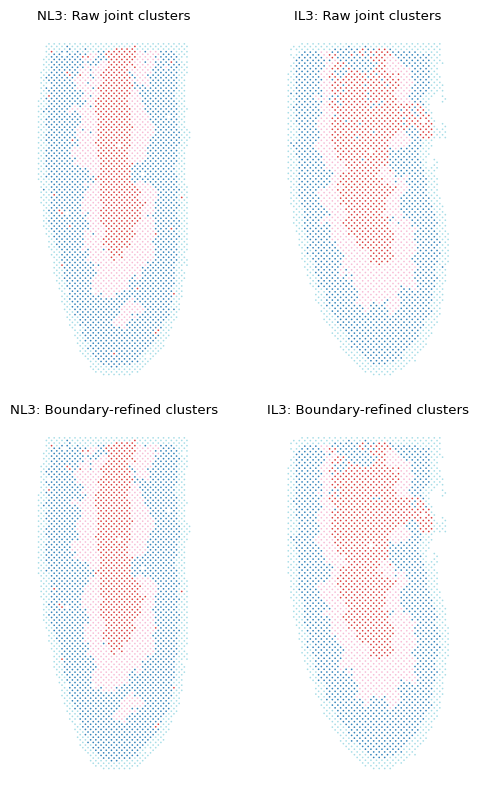

,n_cells,n_changed,pct_changed,n_boundary,n_boundary_changed,n_protected_changed
IL3,2965.0,31.0,0.010455,2965.0,31.0,1.0
NL3,3215.0,26.0,0.008087,3215.0,26.0,6.0


In [4]:
fig, axes = spAlignDE.plot_joint_cluster_refinement(
    adata_clustered,
    samples=["NL3", "IL3"],
    point_size=1.5,
    palette="tab20",
    alpha=0.9,
    figsize=(6, 8),
)
plt.show()
clustering_details["refinement_stats"]

## Save the clustered kidney AnnData

The alignment notebook uses the refined `cluster` labels while
retaining `cluster_raw` and `cluster_refined` for inspection.

In [5]:
clustered_path = OUTPUT_DIR / "kidney_IL3_NL3_joint_clustered.h5ad"
adata_clustered.write_h5ad(clustered_path)
print("Saved:", clustered_path.relative_to(PROJECT_ROOT))
print("Output shape:", adata_clustered.shape)
print("Cluster columns:", ["cluster_raw", "cluster_refined", "cluster"])

Saved: tutorials/cross_sample/kidney/output/kidney_IL3_NL3_joint_clustered.h5ad
Output shape: (6180, 12697)
Cluster columns: ['cluster_raw', 'cluster_refined', 'cluster']
